# 2 Modelo ARIMA: 

ARIMA es uno de los enfoques más utilizados para la previsión de series temporales y se puede utilizar de dos maneras diferentes en función del tipo de datos de series temporales con los que se trabaje. En el primer caso, un modelo ARIMA no estacional que no requiere tener en cuenta la estacionalidad en sus datos de series temporales. Predecimos el futuro simplemente basándonos en patrones en los datos pasados. En el segundo caso, tenemos en cuenta la estacionalidad, que son los ciclos regulares que afectan a la serie temporal. Estos ciclos pueden ser diarios, semanales, mensuales, etc... y ayudan a definir patrones en los datos pasados de la serie temporal que se pueden utilizar para pronosticar valores futuros.

## 2.1 Significado de ARIMA(p, d, q)

ARIMA es un acrónimo de:

AR (p) = AutoRegresivo, es decir el presente depende de valores pasados
I(d) = Integral, quitamos tendencia (hacemos la serie estable)
MA (q) = Media Movil, el presente depende de errores pasados

## 2.2 Autoregresivo

En un modelo de autorregresión, pronosticamos la variable de interés utilizando una combinación lineal de valores pasados de la variable. El término autorregresión indica que se trata de una regresión de la variable contra sí misma. Esta técnica es similar a un modelo de regresión lineal en cuanto a que utiliza los valores del pasado como entradas para la regresión. La autorregresión se define como:

## 2.3 Media Movil

## 2.4 Integral

## 2.5 Autocorrelación




### Ejemplo código python:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox



# ------------------------------
# 1. Cargar los datos
# ------------------------------
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")

# Ver las primeras filas
print(df.columns.tolist())
# ------------------------------
# 2. Preparar la serie temporal
# ------------------------------
# Convertir la columna de datetime a tipo datetime y ponerla como indice
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)


# Seleccionamos la columna de precio (la que queremos predecir)
#serie = df['price']   # precio podria contener valores nulos, por si acaso
serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna() #quitamos valores erroneos

# Comprobar si hay fechas u horas repetidas
print("¿Hay duplicados en el índice?", serie.index.duplicated().any())

duplicados = serie.index[serie.index.duplicated(keep=False)].unique()
print("Índices duplicados:", duplicados[:10])  # muestra los primeros 10 repetdos
# Asigna frecuencia, para nosostros h para una frecuencia en horas
serie = serie.asfreq('h')   # o 'd' para dias

['datetime', 'price', 'hour']
¿Hay duplicados en el índice? False
Índices duplicados: DatetimeIndex([], dtype='datetime64[us]', name='datetime', freq=None)


Tamaño entrenamiento: 39848 horas (1660 días)
Tamaño prueba:        4000 horas  (167 días)
Porcentaje test:      9.1%


c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Jaime_Sanchez\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                39848
Model:                 ARIMA(2, 1, 1)   Log Likelihood             -149870.535
Date:                Wed, 29 Apr 2026   AIC                         299749.069
Time:                        12:25:57   BIC                         299783.440
Sample:                    01-01-2020   HQIC                        299759.950
                         - 07-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3094      0.002    540.578      0.000       1.305       1.314
ar.L2         -0.4897      0.002   -221.908      0.000      -0.494      -0.485
ma.L1         -0.9391      0.001   -637.169      0.0

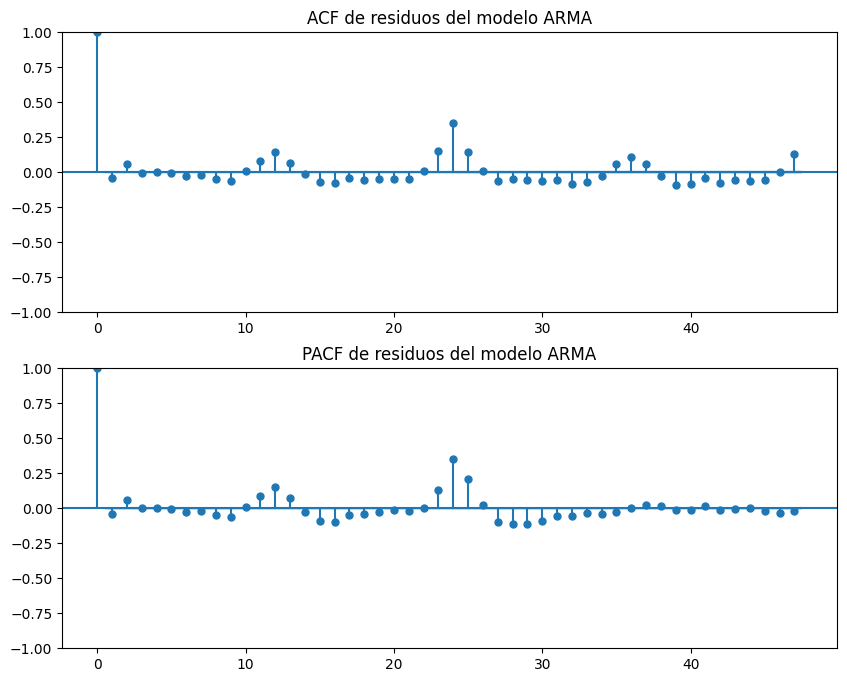


TEST LJUNG-BOX
       lb_stat     lb_pvalue
10  490.225659  5.410279e-99
los residuos NO son ruido blanco (tienen estructura/autocorrelacion)

========== MÉTRICAS DE PRECISIÓN ==========
  MAE   (Error Absoluto Medio):        33.1575 €/MWh
  RMSE  (Raíz Error Cuadrático Medio): 43.0469 €/MWh
  MAPE  (Error Porcentual Medio):       1046326774137164416.00%
  R²    (Coeficiente determinación):    -0.0537
  RMSE modelo naive (benchmark):        13.9340 €/MWh
  El modelo es PEOR que el naive



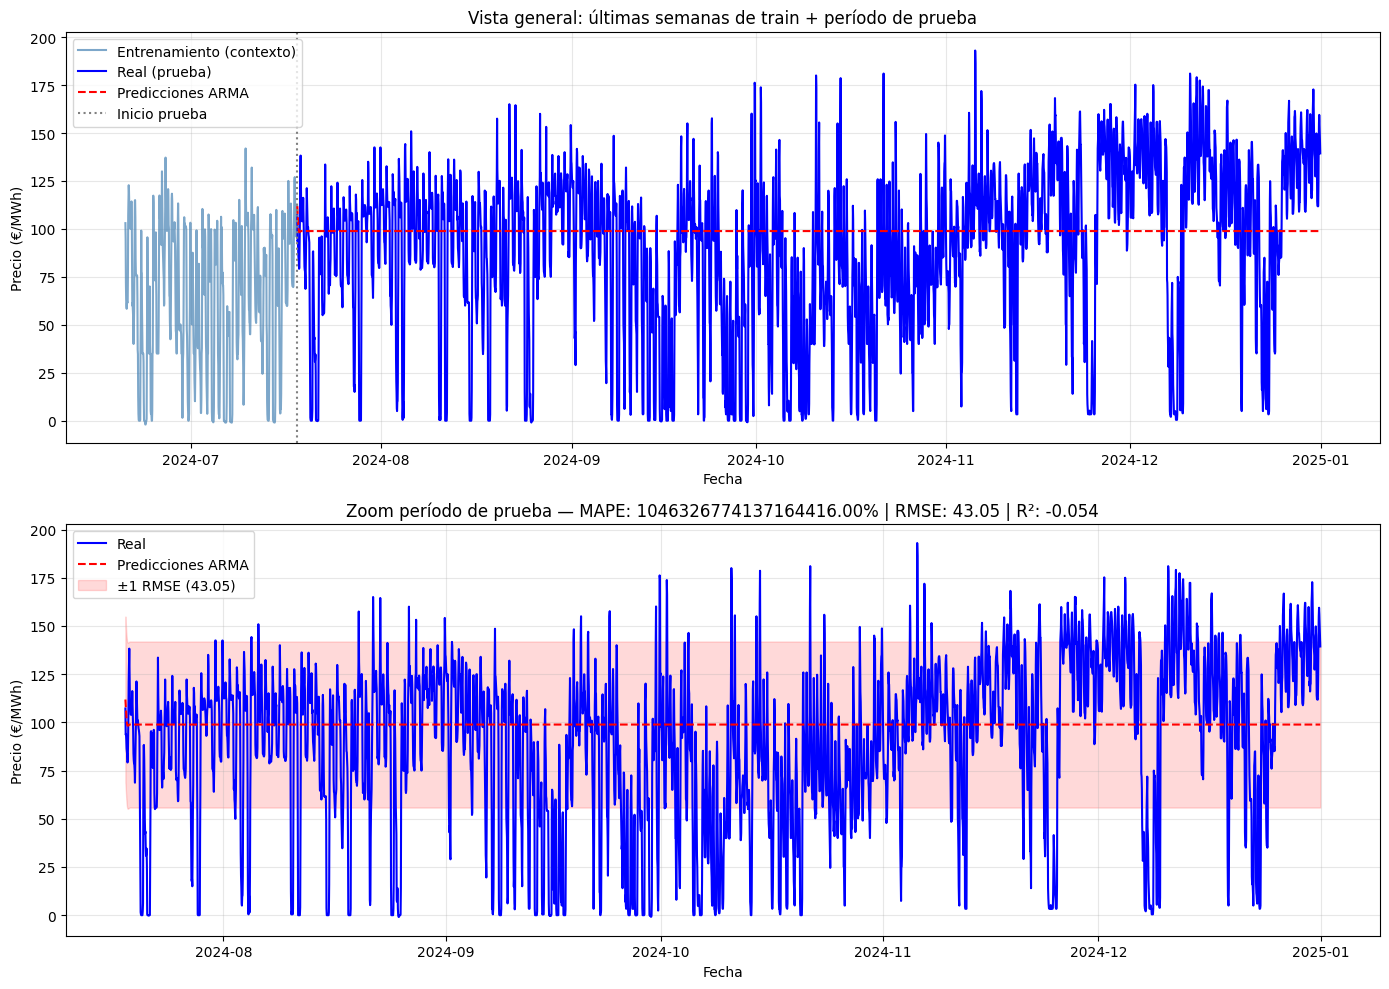

In [ ]:
# ==============================
# 4. CORREGIDO División en entrenamiento y prueba
# ==============================
# ultimas  semanas del dataset (4000 horas) para test, mas representativo
TEST_HOURS = 4000  #

train = serie[:-TEST_HOURS]
test  = serie[-TEST_HOURS:]

print(f"Tamaño entrenamiento: {len(train)} horas ({len(train)/24:.0f} días)")
print(f"Tamaño prueba:        {len(test)} horas  ({len(test)/24:.0f} días)")
print(f"Porcentaje test:      {100*len(test)/len(serie):.1f}%")

# ==============================
# 5. Elegir los órdenes p y q del modelo ARIMA
# ==============================
# En Box-Jenkins a partir de los gráficos de ACF y PACF, elegimos p y q
# En nuestro caso fueron p=2 y q=1
# El valor d e sel numero de diferenciaciones para hacer la serie estacionaria,
#  pero como la serie ya es estacionaria, no es necesario diferenciar (d=0)
#  aunque se puede poner d=1 sin que cambie el resultado matemático porque
#  ARIMA con d=1 en una serie ya estacionaria es equivalente a ARMA con d=0
p = 2
d = 1
q = 1
# En ARIMA, el orden es (p, d, q).
modelo = ARIMA(train, order=(p, d, q))

# Ajustar el modelo
modelo_ajustado = modelo.fit()

# Mostrar un resumen del modelo
print(modelo_ajustado.summary())


# ==============================
# 5.2. Verificar residuos (validación)
# ==============================

# Verificar residuos (validación)
residuos = modelo_ajustado.resid

# Gráfico ACF de residuos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(residuos, ax=axes[0])
axes[0].set_title('ACF de residuos del modelo ARMA')

plot_pacf(residuos, ax=axes[1])
axes[1].set_title('PACF de residuos del modelo ARMA')
plt.show()

# Prueba de Ljung-Box (si p-value > 0.05 los residuos son ruido blanco)
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"\nTEST LJUNG-BOX")
print(lb_test.to_string())
if (lb_test['lb_pvalue'] > 0.05).all():
    print("los residuos son ruido blanco")
else:
    print("los residuos NO son ruido blanco (tienen estructura/autocorrelacion)")

# ==============================
# 6. Predecir los valores del conjunto de prueba
# ==============================
# forecast recibe el número de pasos a predecir
predicciones = modelo_ajustado.forecast(steps=len(test))
predicciones.index = test.index   # para que luego se pueda gaficar bien

# ==============================
# 7. AMPLIADA - Métricas de precisión
# ==============================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = mean_absolute_percentage_error(test, predicciones) * 100

# Métrica adicional: R² (qué % de varianza explica el modelo)
ss_res = np.sum((test - predicciones) ** 2)
ss_tot = np.sum((test - test.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Naive benchmark: predecir siempre el valor anterior (lag-1)
naive_pred = test.shift(1).dropna()
rmse_naive = np.sqrt(mean_squared_error(test[1:], naive_pred))

print("\n========== MÉTRICAS DE PRECISIÓN ==========")
print(f"  MAE   (Error Absoluto Medio):        {mae:.4f} €/MWh")
print(f"  RMSE  (Raíz Error Cuadrático Medio): {rmse:.4f} €/MWh")
print(f"  MAPE  (Error Porcentual Medio):       {mape:.2f}%")
print(f"  R²    (Coeficiente determinación):    {r2:.4f}")
print(f"  RMSE modelo naive (benchmark):        {rmse_naive:.4f} €/MWh")
print(f"  El modelo es {'MEJOR' if rmse < rmse_naive else 'PEOR'} que el naive")
print("============================================\n")

# ==============================
# 8. CORREGIDA - Gráficas con zoom y separadas
# ==============================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Gráfica 1: visión global (últimas 4 semanas de train + todo el test) ---
CONTEXTO = 672  # horas de entrenamiento que se muestran como contexto

ax1 = axes[0]
ax1.plot(train[-CONTEXTO:].index, train[-CONTEXTO:],
         label='Entrenamiento (contexto)', color='steelblue', alpha=0.7)
ax1.plot(test.index, test,
         label='Real (prueba)', color='blue', linewidth=1.5)
ax1.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.5,
            label='Inicio prueba')
ax1.set_title('Vista general: últimas semanas de train + período de prueba')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Precio (€/MWh)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Gráfica 2: zoom solo en el período de prueba ---
ax2 = axes[1]
ax2.plot(test.index, test,
         label='Real', color='blue', linewidth=1.5)
ax2.plot(test.index, predicciones,
         label='Predicciones ARMA', color='red', linestyle='--', linewidth=1.5)
ax2.fill_between(test.index,
                 predicciones - rmse,
                 predicciones + rmse,
                 alpha=0.15, color='red', label=f'±1 RMSE ({rmse:.2f})')
ax2.set_title(f'Zoom período de prueba — MAPE: {mape:.2f}% | RMSE: {rmse:.2f} | R²: {r2:.3f}')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Precio (€/MWh)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arma_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()

Resultado:

Aunque la serie es estacionaria según el test ADF, los modelos ARMA/ARIMA no capturan adecuadamente la estructura de dependencia temporal debido a la presencia de estacionalidad, lo que se traduce en un bajo rendimiento predictivo.

El problema no es la no estacionariedad, es:

Estacionalidad NO modelada. La serie puede ser estacionaria en media pero tener patrones periódicos (diarios, semanales...). ARMA no captura eso bien, por eso:

ACF tiene picos en lags tipo 24, 48, etc.
Y el modelo falla en la predicción



Esto justifica el uso de modelos SARIMA, que incorporan componentes estacionales explícitos.